# trajkit × Geolife

A walk through the end-to-end pipeline on one Geolife user. Each
section anchors a design decision in the code to something visible on a
real GPS trace.

The two headline ideas:

1. **Segmentation that splits on motion state and on sustained
   direction change.** Hysteresis avoids flicker; the multi-scale
   circular-R bearing detector splits long `MOVE` segments where the
   trajectory actually turns.
2. **Similarity search over per-segment vectors.** With trips pooled
   from their constituent segments, "find me trips like this one"
   becomes a cosine query against a FAISS index — returning hits that
   match on behaviour shape, not geography.

The flow is **pings → segments → episodes → similarity**.

## Setup

In [1]:
from pathlib import Path
import os
import sys
import warnings

warnings.filterwarnings("ignore", category=FutureWarning)

import folium
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Local Geolife reader
sys.path.insert(0, str(Path.cwd()))
sys.path.insert(0, "examples/geolife")
from reader import read_user  # noqa: E402

from trajkit.clean import CleanParams, clean  # noqa: E402
from trajkit.compare import build_index, search  # noqa: E402
from trajkit.embed import EmbedParams, embed_segments  # noqa: E402
from trajkit.episode import EpisodeParams, detect_episodes  # noqa: E402
from trajkit.segment import SegmentParams, aggregate_segments  # noqa: E402
from trajkit.segment import segment as run_segment  # noqa: E402

GEOLIFE_DATA = Path(os.path.expanduser("~/.cache/trajkit/Geolife Trajectories 1.3/Data"))
USER_ID = "000"
TIME_WINDOW_DAYS = 7

# Pedestrian-scale calibration for Geolife.
SEG_PARAMS = SegmentParams(
    stop_speed_kmh=1.0, resume_speed_kmh=3.0, max_stop_displacement_m=50.0
)
EP_PARAMS = EpisodeParams(R_m=30.0, T_s=120.0, min_stay_s=120.0)
EMBED_PARAMS = EmbedParams(spatial_bounds=(39.5, 40.5, 115.5, 117.5))
CLEAN_PARAMS = CleanParams()

# Four widely-separated hues from the Okabe-Ito colour-blind safe
# palette. Spans the wheel (blue, green, magenta, vermillion) rather
# than clustering in hue families, so no two segment types look
# similar at a glance — including under deuteranopia / protanopia /
# tritanopia.
COLOUR = {
    "MOVE": "#0072B2",        # blue
    "MOVE_BRIEF": "#009E73",  # green
    "STOP_BRIEF": "#CC79A7",  # magenta
    "STOP_DWELL": "#D55E00",  # vermillion
}

legend_html = """
<div style='position: fixed; top:10px; right:10px; z-index:9999;
            background:white; padding:8px; border:1px solid #888; font-size:13px;'>
  <b>Segment type</b><br>
  <span style='color:#0072B2'>━━━</span> MOVE<br>
  <span style='color:#009E73'>━━━</span> MOVE_BRIEF<br>
  <span style='color:#CC79A7'>━━━</span> STOP_BRIEF<br>
  <span style='color:#D55E00'>━━━</span> STOP_DWELL<br>
</div>
"""

## 1. Load Geolife user

In [2]:
all_pings = read_user(GEOLIFE_DATA / USER_ID, entity_id=USER_ID)
print(f"User {USER_ID}: {len(all_pings):,} pings spanning "
      f"{all_pings['ts'].min().date()} → {all_pings['ts'].max().date()}")

day_counts = all_pings["ts"].dt.floor("D").value_counts().sort_values(ascending=False)
busiest_day = day_counts.index[0]
window_start = busiest_day - pd.Timedelta(days=TIME_WINDOW_DAYS // 2)
window_end = window_start + pd.Timedelta(days=TIME_WINDOW_DAYS)
mask = (all_pings["ts"] >= window_start) & (all_pings["ts"] < window_end)
pings = all_pings.loc[mask].reset_index(drop=True)
print(f"Window: {window_start.date()} → {window_end.date()}  "
      f"({len(pings):,} pings)")

User 000: 173,870 pings spanning 2008-10-23 → 2009-07-05
Window: 2009-03-31 → 2009-04-07  (23,603 pings)


## 2. Run the pipeline

The L1 functions compose explicitly — no orchestrator, no on-disk
persistence. Everything stays in memory for the rest of the notebook.

In [3]:
cleaned_per_ping = clean(pings, CLEAN_PARAMS)
per_ping_segmented = run_segment(cleaned_per_ping, SEG_PARAMS)
segments = aggregate_segments(per_ping_segmented, SEG_PARAMS)
episodes = detect_episodes(segments, EP_PARAMS)
seg_vectors, seg_ids = embed_segments(segments, EMBED_PARAMS)

# Pack the segment vectors into a VectorsSchema-shaped DataFrame so later
# cells can lookup vectors by id without juggling raw arrays.
seg_vectors_df = pd.DataFrame(
    {
        "id": pd.Series(seg_ids, dtype="string"),
        "entity_id": pd.Series([USER_ID] * len(seg_ids), dtype="string"),
        "vector": [seg_vectors[i].astype(np.float32) for i in range(len(seg_ids))],
    }
)
print(f"Pings (cleaned):       {len(per_ping_segmented):>7,}")
print(f"Segments (aggregated): {len(segments):>7,}")
print(f"Episodes:              {len(episodes):>7,} "
      f"(STAY={(episodes['episode_type']=='STAY').sum()}, "
      f"TRANSIT={(episodes['episode_type']=='TRANSIT').sum()})")

Pings (cleaned):        23,603
Segments (aggregated):     937
Episodes:                  176 (STAY=92, TRANSIT=84)


## 3. Pings → Segments → Episodes

A three-level hierarchy:

* **Ping** — one GPS observation. Raw input.
* **Segment** — a contiguous run of pings sharing one of
  `MOVE`, `MOVE_BRIEF`, `STOP_BRIEF`, `STOP_DWELL`.
* **Episode** — a contiguous run of segments sharing one of
  `STAY` or `TRANSIT`, decided by the spatial-envelope rule.

One real example below.

In [4]:
# Show one episode's nested structure
sample_ep = episodes[episodes["episode_type"] == "TRANSIT"].sort_values(
    "n_segments", ascending=False
).iloc[0]
print(
    f"Episode {sample_ep['episode_id']}  "
    f"({sample_ep['episode_type']}, {sample_ep['duration_s']:.0f}s, "
    f"{int(sample_ep['n_segments'])} segments, "
    f"{float(sample_ep['path_length_m']):.0f}m path)"
)
print()
print("├── segments (one per row, time-ordered):")
for seg_id in sample_ep["segment_ids"]:
    seg = segments.loc[segments["segment_id"] == seg_id].iloc[0]
    n_pings = (per_ping_segmented["segment_id"] == seg_id).sum()
    print(
        f"│   ├── {seg_id}  "
        f"{seg['segment_type']:<11s}  {seg['duration_s']:>5.0f}s  "
        f"path={seg['path_length_m']:>6.0f}m  pings={n_pings}"
    )
print("│")
print("└── (each segment in turn is a contiguous run of pings)")

Episode ep_000_00150  (TRANSIT, 3968s, 25 segments, 13335m path)

├── segments (one per row, time-ordered):
│   ├── 000_seg_00828  MOVE           145s  path=   638m  pings=32
│   ├── 000_seg_00829  STOP_BRIEF      65s  path=    15m  pings=16
│   ├── 000_seg_00830  MOVE           145s  path=   809m  pings=31
│   ├── 000_seg_00831  MOVE           285s  path=  1454m  pings=59
│   ├── 000_seg_00832  MOVE           355s  path=   693m  pings=75
│   ├── 000_seg_00833  MOVE            45s  path=    34m  pings=11
│   ├── 000_seg_00834  STOP_BRIEF      60s  path=     7m  pings=15
│   ├── 000_seg_00835  MOVE            90s  path=   850m  pings=19
│   ├── 000_seg_00836  MOVE            60s  path=   375m  pings=14
│   ├── 000_seg_00837  MOVE           125s  path=   675m  pings=27
│   ├── 000_seg_00838  MOVE            90s  path=   607m  pings=20
│   ├── 000_seg_00839  MOVE           420s  path=  2340m  pings=92
│   ├── 000_seg_00840  MOVE           110s  path=   573m  pings=24
│   ├── 000_seg_00841

One TRANSIT episode wraps several typed segments, each itself a run of
dozens of pings. Ping-level is too granular to ask "what kind of trip
is this?"; segment-level is too noisy; episode-level is the right grain.

## 4. Segment-type breakdown

Atomic count + total duration share per segment type.

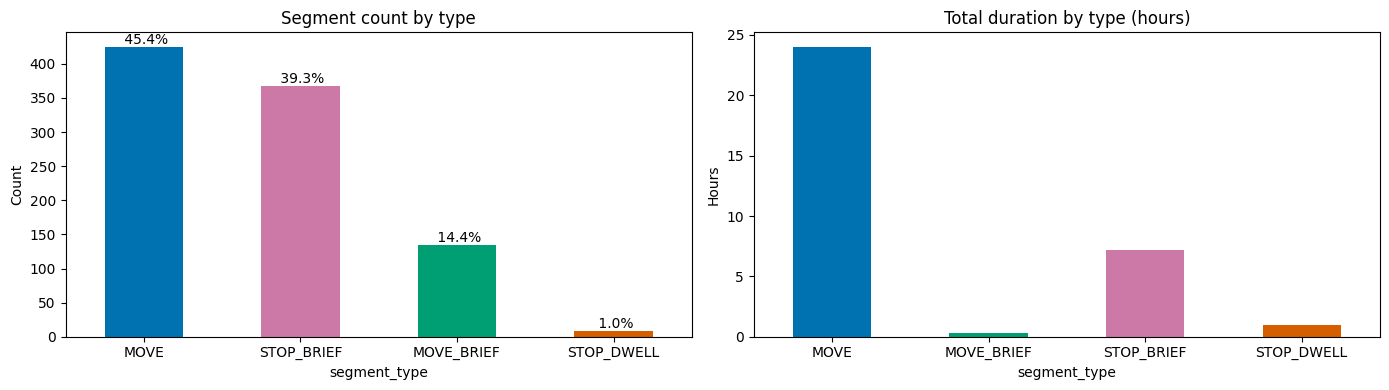

In [5]:
type_counts = segments["segment_type"].value_counts()
fig, ax = plt.subplots(1, 2, figsize=(14, 4))
type_counts.plot.bar(ax=ax[0], color=[COLOUR.get(t, "#888") for t in type_counts.index])
ax[0].set_title("Segment count by type")
ax[0].set_ylabel("Count")
ax[0].tick_params(axis="x", rotation=0)
fractions = (type_counts / type_counts.sum() * 100).round(1)
for i in range(len(type_counts)):
    ax[0].text(i, type_counts.iloc[i], f" {fractions.iloc[i]}%", ha="center", va="bottom")
type_total_duration = segments.groupby("segment_type")["duration_s"].sum() / 3600
type_total_duration.plot.bar(ax=ax[1], color=[COLOUR.get(t, "#888") for t in type_total_duration.index])
ax[1].set_title("Total duration by type (hours)")
ax[1].set_ylabel("Hours")
ax[1].tick_params(axis="x", rotation=0)
plt.tight_layout()
plt.show()

## 5. Hysteresis at work

The state machine has a *dead zone* between `stop_speed_kmh` and
`resume_speed_kmh`. While speed is in the dead zone, the inferred
state stays put. The plot below zooms into a boundary region scored
for non-trivial dead-zone activity. The speed line repeatedly dips
into the dead zone without flipping the state band underneath — that
stability is the whole point of using two thresholds.

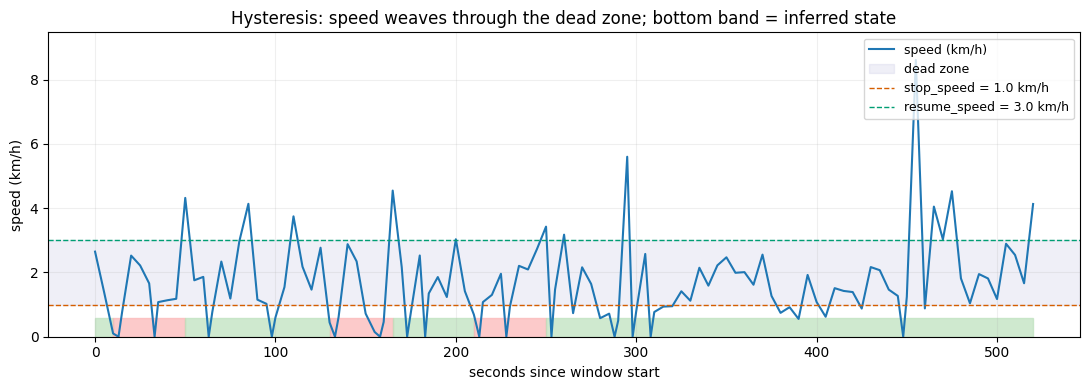

window: 66 dead-zone pings out of 120; state transitions: 6


In [6]:
_per_ping = per_ping_segmented.copy()
_per_ping["_is_stop"] = _per_ping["segment_type"].str.startswith("STOP")
_per_ping["_state_change"] = _per_ping["_is_stop"] != _per_ping["_is_stop"].shift(
    1, fill_value=_per_ping["_is_stop"].iloc[0]
)
stop_ms_ = SEG_PARAMS.stop_speed_kmh * (1000.0 / 3600.0)
resume_ms_ = SEG_PARAMS.resume_speed_kmh * (1000.0 / 3600.0)
ds = _per_ping["speed_ms"].fillna(0.0).to_numpy()
in_dead = (ds > stop_ms_) & (ds < resume_ms_)

_WIN = 120
_csum = np.concatenate([[0], np.cumsum(in_dead.astype(int))])
_best_idx, _best_score = None, -1
for b in _per_ping.index[_per_ping["_state_change"]]:
    lo = max(0, int(b) - _WIN // 2)
    hi = min(len(_per_ping), int(b) + _WIN // 2)
    score = int(in_dead[lo:hi].sum())
    if score > _best_score:
        _best_score, _best_idx = score, int(b)

if _best_idx is None:
    print("no state transitions in this slice — hysteresis demo skipped")
else:
    lo = max(0, _best_idx - _WIN // 2)
    hi = min(len(_per_ping), _best_idx + _WIN // 2)
    view = _per_ping.iloc[lo:hi].reset_index(drop=True)
    speed_kmh = view["speed_ms"].fillna(0.0) * 3.6
    elapsed_s = (view["ts"] - view["ts"].iloc[0]).dt.total_seconds()
    state = view["_is_stop"].to_numpy()

    fig, ax = plt.subplots(figsize=(11, 4))
    ax.plot(elapsed_s, speed_kmh, color="#1f77b4", lw=1.5, label="speed (km/h)")
    ax.axhspan(SEG_PARAMS.stop_speed_kmh, SEG_PARAMS.resume_speed_kmh,
               color="#9999cc", alpha=0.15, label="dead zone")
    ax.axhline(SEG_PARAMS.stop_speed_kmh, color="#D55E00", lw=1, ls="--",
               label=f"stop_speed = {SEG_PARAMS.stop_speed_kmh} km/h")
    ax.axhline(SEG_PARAMS.resume_speed_kmh, color="#009E73", lw=1, ls="--",
               label=f"resume_speed = {SEG_PARAMS.resume_speed_kmh} km/h")
    prev_s, band_start = state[0], 0
    for k in range(1, len(state) + 1):
        if k == len(state) or state[k] != prev_s:
            colour = "#fbb4b4" if prev_s else "#bbe1bb"
            ax.axvspan(elapsed_s.iloc[band_start],
                       elapsed_s.iloc[min(k, len(state) - 1)],
                       ymax=0.06, color=colour, alpha=0.7)
            if k < len(state):
                band_start, prev_s = k, state[k]
    ax.set_ylim(0, max(float(speed_kmh.max()) * 1.1, SEG_PARAMS.resume_speed_kmh * 1.5))
    ax.set_xlabel("seconds since window start")
    ax.set_ylabel("speed (km/h)")
    ax.set_title("Hysteresis: speed weaves through the dead zone; bottom band = inferred state")
    ax.legend(loc="upper right", fontsize=9)
    ax.grid(True, alpha=0.2)
    plt.tight_layout(); plt.show()
    print(f"window: {_best_score} dead-zone pings out of {hi - lo}; "
          f"state transitions: {int(view['_state_change'].sum())}")

## 6. Why `GAP_FOLLOWS` outranks `DRIFT`

The cleaning layer's flag precedence is
`DEVICE_FAULT > SPEED_OUTLIER > GAP_FOLLOWS > DRIFT > VALID`. The
non-obvious choice is `GAP_FOLLOWS > DRIFT`. A ping after a long gap
has a tiny implied displacement and a near-zero effective speed only
because the position was sampled minutes or hours apart — the drift
heuristic would mis-claim it as drift, and the segmenter would then
see no gap boundary and grow segments straight across the missing
interval.

Below: for every `GAP_FOLLOWS` ping in the trace, what would the
naive "drift first" rule have said?

In [7]:
_drift_ms = CLEAN_PARAMS.drift_speed_kmh * (1000.0 / 3600.0)
_gap_mask = (cleaned_per_ping["quality_flag"] == "GAP_FOLLOWS").to_numpy()

# Re-derive raw kinematics that drift would have inspected, ignoring the
# gap-edge nulling that clean() performs.
_lat = cleaned_per_ping["lat"].to_numpy()
_lon = cleaned_per_ping["lon"].to_numpy()
_prev_lat = np.concatenate([[np.nan], _lat[:-1]])
_prev_lon = np.concatenate([[np.nan], _lon[:-1]])
_dt = cleaned_per_ping["dt_seconds"].to_numpy()
_EARTH = 6_371_000.0
_phi1, _phi2 = np.radians(_prev_lat), np.radians(_lat)
_dphi = np.radians(_lat - _prev_lat)
_dlmb = np.radians(_lon - _prev_lon)
_a = np.sin(_dphi / 2) ** 2 + np.cos(_phi1) * np.cos(_phi2) * np.sin(_dlmb / 2) ** 2
_raw_disp = 2 * _EARTH * np.arcsin(np.sqrt(_a))
_raw_disp = np.where(np.isnan(_raw_disp), 0.0, _raw_disp)
with np.errstate(divide="ignore", invalid="ignore"):
    _raw_speed_ms = np.where(_dt > 0, _raw_disp / _dt, np.inf)

_would_be_drift = (
    (_raw_disp > 0)
    & (_raw_disp < CLEAN_PARAMS.drift_radius_m)
    & (_raw_speed_ms < _drift_ms)
)
_caught_by_precedence = int((_gap_mask & _would_be_drift).sum())
_total_gap = int(_gap_mask.sum())
print(
    f"GAP_FOLLOWS pings: {_total_gap}\n"
    f"  would have been DRIFT under naive ordering: {_caught_by_precedence}"
    f"  ({100 * _caught_by_precedence / max(_total_gap, 1):.1f}%)"
)

_sample_rows = []
for idx in np.where(_gap_mask)[0][:6]:
    _sample_rows.append({
        "row": int(idx),
        "dt_h": round(float(_dt[idx]) / 3600.0, 2),
        "raw_disp_m": round(float(_raw_disp[idx]), 1),
        "raw_speed_kmh": round(float(_raw_speed_ms[idx]) * 3.6, 3),
        "naive_DRIFT_would_fire": bool(
            _raw_disp[idx] > 0
            and _raw_disp[idx] < CLEAN_PARAMS.drift_radius_m
            and _raw_speed_ms[idx] < _drift_ms
        ),
    })
print()
print(pd.DataFrame(_sample_rows).to_string(index=False))

GAP_FOLLOWS pings: 85
  would have been DRIFT under naive ordering: 61  (71.8%)

 row  dt_h  raw_disp_m  raw_speed_kmh  naive_DRIFT_would_fire
 131  0.17        28.0          0.165                    True
 254  0.11        28.8          0.263                    True
 348  0.25        23.3          0.094                    True
 417  2.02        27.4          0.014                    True
 528  0.09        43.0          0.469                    True
 539  0.24       176.4          0.739                   False


Most gap-edge pings have tiny implied displacement (the device pinged
from nearly the same place after a multi-hour silence). Without the
precedence rule those would be labelled `DRIFT`, no gap boundary
would fire in the segmenter, and a segment would grow straight across
the unobserved interval. The precedence is what keeps that from
happening.

## 7. Map: segments along the actual ping path

Two views of the same segmentation. The first map traces the **actual
GPS pings** of each segment — segments respect the natural shape of the
trajectory because they are runs of consecutive pings. The second map
collapses each segment to a single **start → end straight line**, the
representation downstream consumers (embeddings, similarity search) work
from. Comparing the two shows how much detail the segment abstraction
discards, and where that abstraction is faithful vs lossy.

In [8]:
center_lat = float(pings["lat"].median())
center_lon = float(pings["lon"].median())

# ── Map 6a: full ping path per segment ──────────────────────────────
m_segments = folium.Map(
    location=[center_lat, center_lon], zoom_start=12, tiles="cartodbpositron"
)

seg_meta = segments.set_index("segment_id")[["segment_type", "duration_s"]]
for seg_id, group in per_ping_segmented.groupby("segment_id", sort=False):
    if len(group) < 2:
        continue
    if seg_id not in seg_meta.index:
        continue
    meta = seg_meta.loc[seg_id]
    seg_type = str(meta["segment_type"])
    coords = list(zip(group["lat"].astype(float), group["lon"].astype(float), strict=True))
    folium.PolyLine(
        locations=coords,
        color=COLOUR.get(seg_type, "#888888"),
        weight=3 if seg_type.startswith("MOVE") else 5,
        opacity=0.6,
        tooltip=(
            f"{seg_id} • {seg_type} • {float(meta['duration_s']):.0f}s • "
            f"pings={len(group)}"
        ),
    ).add_to(m_segments)

m_segments.get_root().html.add_child(folium.Element(legend_html))
m_segments.save("segments_map.html")
m_segments

### Map 6b: simplified — each segment as a start → end straight line

Same colour encoding. A straight chord between `(start_lat, start_lon)`
and `(end_lat, end_lon)` for every segment. Curvy MOVE segments shrink
to short chords (low straightness); near-stationary STOP segments
collapse to a point or near-point.

In [9]:
m_segments_simplified = folium.Map(
    location=[center_lat, center_lon], zoom_start=12, tiles="cartodbpositron"
)
for _, seg in segments.iterrows():
    seg_type = str(seg["segment_type"])
    folium.PolyLine(
        locations=[
            (float(seg["start_lat"]), float(seg["start_lon"])),
            (float(seg["end_lat"]), float(seg["end_lon"])),
        ],
        color=COLOUR.get(seg_type, "#888888"),
        weight=3 if seg_type.startswith("MOVE") else 5,
        opacity=0.6,
        tooltip=(
            f"{seg['segment_id']} • {seg_type} • "
            f"{float(seg['duration_s']):.0f}s • "
            f"path={float(seg['path_length_m']):.0f}m • "
            f"chord={float(seg['displacement_m']):.0f}m • "
            f"straightness={float(seg['straightness']):.2f}"
        ),
    ).add_to(m_segments_simplified)

m_segments_simplified.get_root().html.add_child(folium.Element(legend_html))
m_segments_simplified.save("segments_simplified_map.html")
m_segments_simplified

## 8. Anatomy of one segment

A segment is a sequence of pings sharing one motion type, not a
straight line. `displacement_m` is the bird's-eye gap;
`path_length_m` is the sum of inter-ping displacements; their ratio
gives `straightness ∈ [0, 1]`.

In [10]:
# Pick a MOVE segment with a representative ping count
move_segments = segments[segments["segment_type"] == "MOVE"].copy()
move_segments["__ping_count"] = move_segments["segment_id"].map(
    per_ping_segmented["segment_id"].value_counts()
)
sample_seg = move_segments.sort_values("__ping_count", ascending=False).iloc[
    len(move_segments) // 4  # pick around the 25th-percentile-from-largest
]
sample_pings = per_ping_segmented[
    per_ping_segmented["segment_id"] == sample_seg["segment_id"]
].sort_values("ts")
print(
    f"Segment: {sample_seg['segment_id']} ({sample_seg['segment_type']})"
)
print(f"  pings:                 {len(sample_pings)}")
print(f"  duration_s:            {sample_seg['duration_s']:.1f}")
print(f"  start → end straight:  {sample_seg['displacement_m']:.1f} m")
print(f"  actual path length:    {sample_seg['path_length_m']:.1f} m")
print(f"  straightness:          {sample_seg['straightness']:.3f}  "
      f"(displacement / path_length)")

# Map zoomed to this segment
seg_center_lat = float(sample_pings["lat"].mean())
seg_center_lon = float(sample_pings["lon"].mean())
m_one_seg = folium.Map(
    location=[seg_center_lat, seg_center_lon], zoom_start=15, tiles="cartodbpositron"
)
# Actual ping path
folium.PolyLine(
    locations=list(zip(sample_pings["lat"].astype(float),
                       sample_pings["lon"].astype(float),
                       strict=True)),
    color=COLOUR[str(sample_seg["segment_type"])],
    weight=4,
    opacity=0.8,
    tooltip=f"actual path: {sample_seg['path_length_m']:.0f}m through "
             f"{len(sample_pings)} pings",
).add_to(m_one_seg)
# Straight-line displacement (dashed grey, for comparison)
folium.PolyLine(
    locations=[(float(sample_seg["start_lat"]), float(sample_seg["start_lon"])),
               (float(sample_seg["end_lat"]), float(sample_seg["end_lon"]))],
    color="#666666", weight=2, opacity=0.6, dash_array="6,6",
    tooltip=f"start → end straight line: {sample_seg['displacement_m']:.0f}m",
).add_to(m_one_seg)
# Markers
folium.CircleMarker(
    location=[float(sample_seg["start_lat"]), float(sample_seg["start_lon"])],
    radius=6, color="#2ca02c", fill=True, fill_opacity=0.9,
    tooltip="segment start",
).add_to(m_one_seg)
folium.CircleMarker(
    location=[float(sample_seg["end_lat"]), float(sample_seg["end_lon"])],
    radius=6, color="#9467bd", fill=True, fill_opacity=0.9,
    tooltip="segment end",
).add_to(m_one_seg)
m_one_seg.save("segment_anatomy.html")
m_one_seg

Segment: 000_seg_00185 (MOVE)
  pings:                 48
  duration_s:            235.0
  start → end straight:  649.0 m
  actual path length:    699.9 m
  straightness:          0.927  (displacement / path_length)


The coloured polyline is the actual pings; the grey dashed line is the
straight-line displacement. A straight commute scores `straightness ≈
1.0`; a winding walk lands closer to 0.3.

## 9. A bearing-driven boundary

Walkthrough of the most novel piece of the pipeline. The bearing
detector splits a long `MOVE` where its direction changes
sustainedly, even if speed never crosses the stop threshold and no
gap is observed.

We do this in three steps:

1. The intuition: what `R` (mean resultant length) actually measures.
2. A real boundary on the map, picked programmatically.
3. The bearings and R curves at that boundary, with coloured markers
   that match the map dots so you can trace any point on the plot
   back to a physical location.

### 9a. The intuition — what is R?

For a window of bearings, take each bearing as a unit vector on the
circle and average them. The length of that **mean unit-vector** is
`R ∈ [0, 1]`:

* If the bearings are clustered (heading stable), the unit vectors
  add constructively and the mean has length close to 1.
* If the bearings are spread (heading changing), the unit vectors
  cancel out and the mean is close to zero.

`R` is the circular-statistics-correct way to ask "how concentrated
are these bearings?", which side-steps the wraparound that ordinary
arithmetic averages run into at 0°/360°.

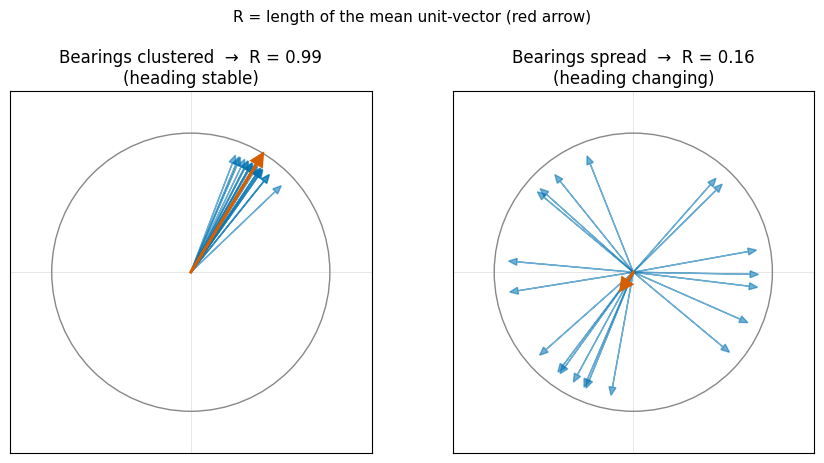

In [11]:
_rng = np.random.default_rng(0)
fig_i, (ax_lo, ax_hi) = plt.subplots(1, 2, figsize=(9, 4.5),
                                     subplot_kw={"aspect": "equal"})
for _ax in (ax_lo, ax_hi):
    _ax.add_patch(plt.Circle((0, 0), 1.0, fill=False, color="#888", lw=1))
    _ax.set_xlim(-1.3, 1.3); _ax.set_ylim(-1.3, 1.3)
    _ax.axhline(0, color="#ddd", lw=0.5, zorder=0)
    _ax.axvline(0, color="#ddd", lw=0.5, zorder=0)
    _ax.set_xticks([]); _ax.set_yticks([])

_angles_lo = np.deg2rad(60 + _rng.normal(0, 7, size=20))
for _a in _angles_lo:
    ax_lo.arrow(0, 0, 0.9 * np.cos(_a), 0.9 * np.sin(_a),
                head_width=0.05, head_length=0.06, color="#0072B2", alpha=0.55,
                length_includes_head=True)
_mean_lo = np.array([np.cos(_angles_lo).mean(), np.sin(_angles_lo).mean()])
_r_lo = float(np.linalg.norm(_mean_lo))
ax_lo.arrow(0, 0, _mean_lo[0], _mean_lo[1], head_width=0.08, head_length=0.08,
            color="#D55E00", lw=2, length_includes_head=True, zorder=5)
ax_lo.set_title(f"Bearings clustered  →  R = {_r_lo:.2f}\n(heading stable)")

_angles_hi = np.deg2rad(_rng.uniform(0, 360, size=20))
for _a in _angles_hi:
    ax_hi.arrow(0, 0, 0.9 * np.cos(_a), 0.9 * np.sin(_a),
                head_width=0.05, head_length=0.06, color="#0072B2", alpha=0.55,
                length_includes_head=True)
_mean_hi = np.array([np.cos(_angles_hi).mean(), np.sin(_angles_hi).mean()])
_r_hi = float(np.linalg.norm(_mean_hi))
ax_hi.arrow(0, 0, _mean_hi[0], _mean_hi[1], head_width=0.08, head_length=0.08,
            color="#D55E00", lw=2, length_includes_head=True, zorder=5)
ax_hi.set_title(f"Bearings spread  →  R = {_r_hi:.2f}\n(heading changing)")
fig_i.suptitle("R = length of the mean unit-vector (red arrow)", fontsize=11, y=1.02)
plt.tight_layout(); plt.show()

### 9b. Find a real boundary

Walk adjacent segment pairs. A *pure* bearing-driven boundary is one
where both segments are `MOVE`, joined at a single ping interval,
and the join ping isn't `GAP_FOLLOWS`. That rules out state-change
and gap as the cause — only the bearing detector could have split
the segments.

In [12]:
from trajkit.segment._segment import _circular_r_over_distance  # noqa: E402

sorted_segs = segments.sort_values("start_ts").reset_index(drop=True)
ctx_pings_before = 30
ctx_pings_after = 120
best = None
for i in range(len(sorted_segs) - 1):
    a, b = sorted_segs.iloc[i], sorted_segs.iloc[i + 1]
    if a["segment_type"] != "MOVE" or b["segment_type"] != "MOVE":
        continue
    if a["n_pings"] < ctx_pings_before or b["n_pings"] < ctx_pings_after:
        continue
    b_first_idx = int(per_ping_segmented.index[
        per_ping_segmented["segment_id"] == b["segment_id"]
    ].min())
    if per_ping_segmented["quality_flag"].iloc[b_first_idx] == "GAP_FOLLOWS":
        continue
    score = float(a["path_length_m"]) + float(b["path_length_m"])
    if best is None or score > best["score"]:
        best = {"prev_id": a["segment_id"], "next_id": b["segment_id"],
                "b_first_idx": b_first_idx, "score": score}
if best is None:
    raise RuntimeError("no MOVE → MOVE boundary found in this slice")

TARGET_SEG = best["next_id"]
prev_seg_id = best["prev_id"]
target_idx0 = best["b_first_idx"]
target_idx_last = int(per_ping_segmented.index[
    per_ping_segmented["segment_id"] == TARGET_SEG
].max())
target_meta = segments.loc[segments["segment_id"] == TARGET_SEG].iloc[0]

# Narrow slice around the boundary — wide enough to see motion on either side
# but not so wide that long-window R averages over uninteresting territory.
r_slice = per_ping_segmented.iloc[
    max(0, target_idx0 - ctx_pings_before) : target_idx0 + ctx_pings_after
].reset_index(drop=True)
boundary_local = int(r_slice.index[r_slice["segment_id"] == TARGET_SEG].min())

print(f"Boundary: {prev_seg_id} (MOVE) → {TARGET_SEG} (MOVE)")
print(f"  target segment: {int(target_meta['n_pings'])} pings, "
      f"{float(target_meta['duration_s']):.0f}s, "
      f"path={float(target_meta['path_length_m']):.0f} m")

# Compute the R curves and the cumulative-distance axis.
moving = r_slice["segment_type"].str.startswith("MOVE").to_numpy()
bearing_arr = r_slice["bearing_deg"].to_numpy(dtype=float)
valid_b = moving & ~np.isnan(bearing_arr)
disp = r_slice["displacement_m"].fillna(0.0).to_numpy(dtype=float)
cum_dist = np.cumsum(np.where(moving, disp, 0.0))
boundary_dist = float(cum_dist[boundary_local])
r_short = _circular_r_over_distance(
    cum_dist, bearing_arr, valid_b,
    SEG_PARAMS.bearing_window_short_m, SEG_PARAMS.bearing_window_min_pings,
)
r_long = _circular_r_over_distance(
    cum_dist, bearing_arr, valid_b,
    SEG_PARAMS.bearing_window_long_m, SEG_PARAMS.bearing_window_min_pings,
)

# Sample N evenly spaced pings as colour anchors. The same colours appear
# on both the map below and the plot in 9c, so any dot can be traced
# from one to the other.
from matplotlib.cm import viridis  # noqa: E402
N_MARKERS = 12
sample_idx = np.linspace(0, len(r_slice) - 1, N_MARKERS).astype(int)
sample_colours = viridis(np.linspace(0.05, 0.95, N_MARKERS))


def _rgb_hex(rgb: np.ndarray) -> str:
    r, g, b = (int(rgb[i] * 255) for i in range(3))
    return f"#{r:02x}{g:02x}{b:02x}"

Boundary: 000_seg_00169 (MOVE) → 000_seg_00170 (MOVE)
  target segment: 204 pings, 1015s, path=19116 m


### Map of the boundary

The polylines show the two `MOVE` segments either side of the boundary
coloured by `segment_type`. The numbered coloured dots are evenly
spaced sample pings — the same colours appear on the bearing and R
curves in 9c, so you can point at any dot on the map and find it on
the plot.

In [13]:
seg_center_lat = float(r_slice["lat"].astype(float).mean())
seg_center_lon = float(r_slice["lon"].astype(float).mean())
m_seg_bearing = folium.Map(
    location=[seg_center_lat, seg_center_lon], zoom_start=13, tiles="cartodbpositron"
)
for sid, group in r_slice.groupby("segment_id", sort=False):
    if len(group) < 2:
        continue
    seg_type = str(group["segment_type"].iloc[0])
    folium.PolyLine(
        locations=list(zip(group["lat"].astype(float),
                           group["lon"].astype(float), strict=True)),
        color=COLOUR.get(seg_type, "#888888"),
        weight=4, opacity=0.55,
        tooltip=f"{sid} ({seg_type})",
    ).add_to(m_seg_bearing)
for _k, _idx in enumerate(sample_idx):
    _r = r_slice.iloc[int(_idx)]
    folium.CircleMarker(
        location=[float(_r["lat"]), float(_r["lon"])],
        radius=8,
        color=_rgb_hex(sample_colours[_k]),
        fill=True, fill_opacity=0.95, weight=2,
        tooltip=f"k={_k}  cum_dist={cum_dist[_idx]:.0f} m  "
                f"bearing={bearing_arr[_idx]:.0f}°",
    ).add_to(m_seg_bearing)
_b_row = r_slice.iloc[boundary_local]
folium.CircleMarker(
    location=[float(_b_row["lat"]), float(_b_row["lon"])],
    radius=10, color="black", fill=True, fill_opacity=0.9, weight=2,
    tooltip=f"boundary: first ping of {TARGET_SEG}",
).add_to(m_seg_bearing)
m_seg_bearing.get_root().html.add_child(folium.Element(legend_html))
m_seg_bearing.save("segment_bearing_anatomy.html")
m_seg_bearing

### 9c. The bearings and R, side by side

**Top panel**: raw bearings (degrees, vs distance along the
trajectory). Heading stays clustered in one direction, then rotates
through the boundary, then clusters in a new direction. Wraparound at
360° → 0° is normal and is precisely what the circular-statistics
treatment avoids.

**Bottom panel**: the same R curves the detector sees. Both windows
(short 75 m, long 200 m) sit close to 1.0 while heading is stable,
then dive sharply through `r_enter` at the boundary. The boundary
itself (vertical dotted line) lines up with where the bearings start
rotating.

Coloured dots correspond to the map markers.

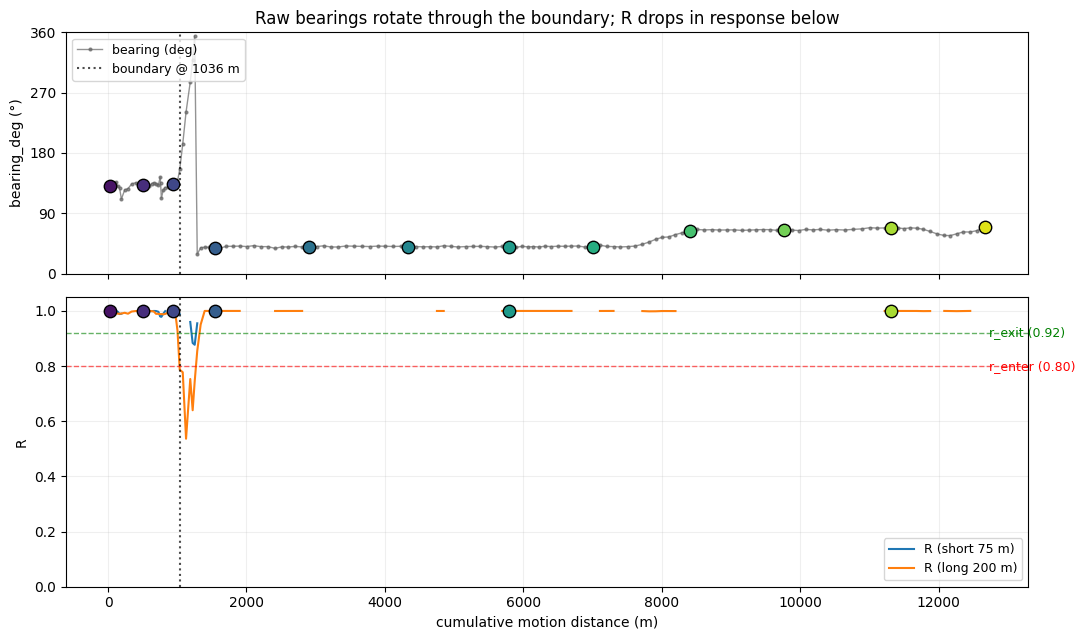

In [14]:
fig, (ax_b, ax_r) = plt.subplots(2, 1, figsize=(11, 6.5), sharex=True,
                                 gridspec_kw={"height_ratios": [1.0, 1.2]})

ax_b.plot(cum_dist[valid_b], bearing_arr[valid_b],
          color="#666", lw=1, alpha=0.7, marker="o", ms=2,
          label="bearing (deg)")
ax_b.axvline(boundary_dist, color="black", ls=":", alpha=0.7, lw=1.5,
             label=f"boundary @ {boundary_dist:.0f} m")
ax_b.set_ylabel("bearing_deg (°)")
ax_b.set_ylim(0, 360); ax_b.set_yticks([0, 90, 180, 270, 360])
ax_b.grid(True, alpha=0.2)
ax_b.legend(fontsize=9, loc="upper left")
ax_b.set_title("Raw bearings rotate through the boundary; R drops in response below")

ax_r.plot(cum_dist, r_short,
          label=f"R (short {SEG_PARAMS.bearing_window_short_m:.0f} m)",
          color="#1f77b4", lw=1.5)
ax_r.plot(cum_dist, r_long,
          label=f"R (long {SEG_PARAMS.bearing_window_long_m:.0f} m)",
          color="#ff7f0e", lw=1.5)
ax_r.axhline(SEG_PARAMS.bearing_r_enter, ls="--", color="red", alpha=0.6, lw=1)
ax_r.axhline(SEG_PARAMS.bearing_r_exit, ls="--", color="green", alpha=0.6, lw=1)
ax_r.text(cum_dist[-1], SEG_PARAMS.bearing_r_enter,
          f" r_enter ({SEG_PARAMS.bearing_r_enter:.2f})",
          color="red", va="center", fontsize=9)
ax_r.text(cum_dist[-1], SEG_PARAMS.bearing_r_exit,
          f" r_exit ({SEG_PARAMS.bearing_r_exit:.2f})",
          color="green", va="center", fontsize=9)
ax_r.axvline(boundary_dist, color="black", ls=":", alpha=0.7, lw=1.5)
ax_r.set_xlabel("cumulative motion distance (m)")
ax_r.set_ylabel("R")
ax_r.set_ylim(0, 1.05)
ax_r.grid(True, alpha=0.2)
ax_r.legend(fontsize=9, loc="lower right")

# Coloured anchor markers on both panels — matched to the map
for _k, _idx in enumerate(sample_idx):
    _cd = cum_dist[_idx]
    _bd = bearing_arr[_idx]
    if not np.isnan(_bd):
        ax_b.scatter(_cd, _bd, s=80, color=sample_colours[_k],
                     edgecolor="black", linewidth=1.0, zorder=10)
    _rs = r_short[_idx]
    if np.isnan(_rs):
        _rs = r_long[_idx]
    if not np.isnan(_rs):
        ax_r.scatter(_cd, _rs, s=80, color=sample_colours[_k],
                     edgecolor="black", linewidth=1.0, zorder=10)
plt.tight_layout(); plt.show()

**Reading guide.** Walk the colours from purple to yellow along the
trajectory. Before the boundary, bearings hold a roughly steady
direction and both R curves sit near 1.0. At the boundary, bearings
rotate sharply — and the short window (75 m, blue) plunges *first*
because the bearing spread is concentrated in a smaller distance
range. The long window (200 m, orange) follows with a delayed,
broader dip. After the boundary, bearings re-cluster around the new
direction and both R curves climb back through `r_exit` (0.92).
*Multi-scale* is the point — the short window catches sharp corners
the long window would smear over; the long window catches arterial
sweeps the short one would miss.

## 10. Segment similarity — *"find me segments like this one"*

A direct demo of the library's primitive embedding. Build a FAISS
index over the per-segment vectors, pick a representative `MOVE`
segment programmatically, fetch the top-5 nearest neighbours by
cosine similarity. If the embedding captures behaviour shape, hits
should match on duration / path-length / straightness — and can land
anywhere geographically. That's "find me a walk like this one,"
regardless of where it happened.

In [15]:
_moves_for_query = segments[
    (segments["segment_type"] == "MOVE")
    & (segments["n_pings"] >= 20)
    & (segments["path_length_m"] >= 200)
].copy()
_median_dur = _moves_for_query["duration_s"].median()
_moves_for_query["__dur_dist"] = (
    _moves_for_query["duration_s"] - _median_dur
).abs()
_query_seg_id = str(
    _moves_for_query.sort_values("__dur_dist").iloc[0]["segment_id"]
)

_seg_index = build_index(seg_vectors, seg_ids, metric="cosine")
_q_idx = seg_ids.index(_query_seg_id)
_seg_hits = search(_seg_index, seg_vectors[_q_idx], k=6)

_seg_hit_rows = []
for _h in _seg_hits:
    _s = segments.loc[segments["segment_id"] == _h.id].iloc[0]
    _seg_hit_rows.append({
        "rank": _h.rank,
        "segment_id": _h.id,
        "score": round(_h.score, 4),
        "type": _s["segment_type"],
        "duration_s": float(_s["duration_s"]),
        "path_m": float(_s["path_length_m"]),
        "straight": round(float(_s["straightness"]), 2),
    })
seg_hits_table = pd.DataFrame(_seg_hit_rows)
print(f"query: {_query_seg_id}")
print(seg_hits_table.to_string(index=False))

# Map: query in black, hits coloured by rank
_RANK_COLOURS = ["#000000", "#d62728", "#ff7f0e", "#2ca02c", "#1f77b4", "#9467bd"]
_q_pings = per_ping_segmented[per_ping_segmented["segment_id"] == _query_seg_id]
_center_lat = float(_q_pings["lat"].astype(float).mean())
_center_lon = float(_q_pings["lon"].astype(float).mean())
m_seg_sim = folium.Map(
    location=[_center_lat, _center_lon], zoom_start=11,
    tiles="cartodbpositron",
)
for _, _row in seg_hits_table.iterrows():
    _sid = _row["segment_id"]
    _sp = per_ping_segmented[per_ping_segmented["segment_id"] == _sid]
    if len(_sp) < 2:
        continue
    _is_query = _row["rank"] == 0
    folium.PolyLine(
        locations=list(zip(_sp["lat"].astype(float),
                           _sp["lon"].astype(float), strict=True)),
        color=("#000000" if _is_query
               else _RANK_COLOURS[int(_row["rank"])]),
        weight=6 if _is_query else 4,
        opacity=0.95 if _is_query else 0.75,
        tooltip=(
            f"rank={int(_row['rank'])} score={_row['score']:.4f} "
            f"{_sid} ({_row['type']}) "
            f"{_row['duration_s']:.0f}s / {_row['path_m']:.0f}m / "
            f"straight={_row['straight']:.2f}"
        ),
    ).add_to(m_seg_sim)
m_seg_sim.save("segment_similarity_map.html")
m_seg_sim

query: 000_seg_00707
 rank    segment_id  score type  duration_s      path_m  straight
    0 000_seg_00707 1.0000 MOVE       280.0 1201.828857      0.75
    1 000_seg_00721 0.9944 MOVE       320.0 1654.824097      0.71
    2 000_seg_00720 0.9915 MOVE       180.0  734.294678      0.81
    3 000_seg_00716 0.9912 MOVE       170.0 1557.287964      0.83
    4 000_seg_00722 0.9909 MOVE       370.0 2344.474121      0.75
    5 000_seg_00712 0.9888 MOVE        90.0  296.765137      0.86


Hits should be of comparable duration, path length, and straightness
to the query, and scattered geographically. That's the embedding
capturing *what* the segment was, not *where* it happened.

## 11. Stay duration distribution

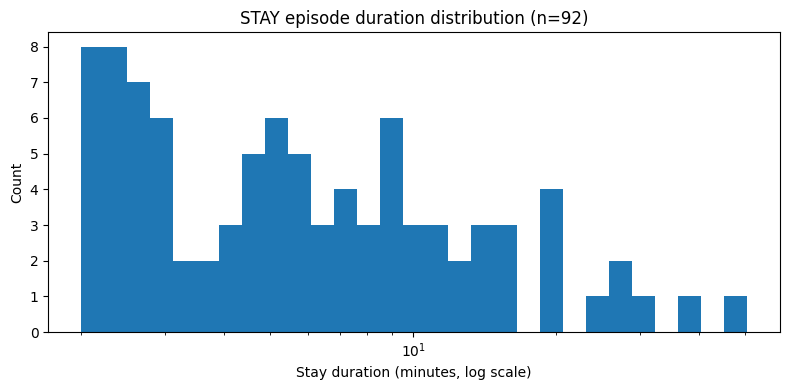

In [16]:
stay_minutes = episodes.loc[episodes["episode_type"] == "STAY", "duration_s"] / 60.0
fig, ax = plt.subplots(1, 1, figsize=(8, 4))
ax.hist(stay_minutes, bins=np.logspace(np.log10(2), np.log10(stay_minutes.max() + 1), 30))
ax.set_xscale("log")
ax.set_xlabel("Stay duration (minutes, log scale)")
ax.set_ylabel("Count")
ax.set_title(f"STAY episode duration distribution (n={len(stay_minutes)})")
plt.tight_layout()
plt.show()

## 12. STAY anchors

In [17]:
stays = episodes[episodes["episode_type"] == "STAY"].copy()
m_stays = folium.Map(
    location=[center_lat, center_lon], zoom_start=12, tiles="cartodbpositron"
)
for _, ep in stays.iterrows():
    duration_min = float(ep["duration_s"]) / 60.0
    radius = float(np.clip(np.log1p(duration_min) * 2.5, 4, 25))
    folium.CircleMarker(
        location=[float(ep["anchor_lat"]), float(ep["anchor_lon"])],
        radius=radius,
        color="#D55E00",  # STAY anchor — matches stopped-warm of the segment palette
        fill=True,
        fill_opacity=0.5,
        tooltip=(
            f"{duration_min:.1f} min • envelope_radius={ep['envelope_radius_m']:.1f} m"
        ),
    ).add_to(m_stays)
m_stays.save("stays_map.html")
m_stays

## 13. Episode dual gate — what the radius check catches

The episode detector applies two qualification gates: a time gate
(`duration ≥ min_stay_s`) and a space gate (`max observed radius from
anchor ≤ R_m`). A centroid-only check would let a spatially extended
single-segment `MOVE` qualify as its own "stay" — its centroid is one
point ≤ R from itself. The space gate rejects those.

Below: how many single segments in this slice would have qualified
under a centroid-only rule but get rejected by the endpoint-reach
check.

In [18]:
def _endpoint_reach(row: pd.Series) -> float:
    cl = (float(row["start_lat"]) + float(row["end_lat"])) / 2.0
    cn = (float(row["start_lon"]) + float(row["end_lon"])) / 2.0
    R = 6_371_000.0
    p1, p2 = np.radians(cl), np.radians([row["start_lat"], row["end_lat"]])
    dphi = np.radians([row["start_lat"] - cl, row["end_lat"] - cl])
    dlmb = np.radians([row["start_lon"] - cn, row["end_lon"] - cn])
    a = np.sin(dphi / 2) ** 2 + np.cos(p1) * np.cos(p2) * np.sin(dlmb / 2) ** 2
    return float(np.max(2 * R * np.arcsin(np.sqrt(a))))


_rejected = segments[
    (segments["duration_s"] >= EP_PARAMS.min_stay_s)
    & segments.apply(lambda r: _endpoint_reach(r) > EP_PARAMS.R_m, axis=1)
].copy()
print(
    f"Single segments that pass duration_s ≥ {EP_PARAMS.min_stay_s:.0f} but fail "
    f"endpoint reach ≤ {EP_PARAMS.R_m:.0f} m: {len(_rejected)}\n"
)
if len(_rejected) > 0:
    _rejected = _rejected.sort_values("duration_s", ascending=False)
    _cols = ["segment_id", "segment_type", "duration_s",
             "path_length_m", "displacement_m", "n_pings"]
    print(_rejected[_cols].head(8).round(1).to_string(index=False))
    print(
        "\nEach of these would have anchored a spurious single-segment stay "
        "under a centroid-only rule. The endpoint-reach gate rejects them."
    )
else:
    print("None found in this slice — the gate didn't reject anything here. "
          "Still useful: tells us this user's traces don't produce endpoint-"
          "stretched candidates at these thresholds.")

Single segments that pass duration_s ≥ 120 but fail endpoint reach ≤ 30 m: 160

   segment_id segment_type  duration_s  path_length_m  displacement_m  n_pings
000_seg_00779         MOVE      1330.0     982.900024      868.900024      225
000_seg_00792         MOVE      1320.0    1268.800049      550.400024      271
000_seg_00876         MOVE      1318.0   23753.300781    18026.099609      265
000_seg_00176         MOVE      1310.0   21967.900391    17600.699219      263
000_seg_00894         MOVE      1255.0   22088.699219    17689.800781      252
000_seg_00636         MOVE      1150.0    1159.699951      773.500000      232
000_seg_00237         MOVE      1040.0     920.099976      159.300003      182
000_seg_00170         MOVE      1015.0   19116.099609    15614.900391      204

Each of these would have anchored a spurious single-segment stay under a centroid-only rule. The endpoint-reach gate rejects them.


## 14. Episode-type breakdown

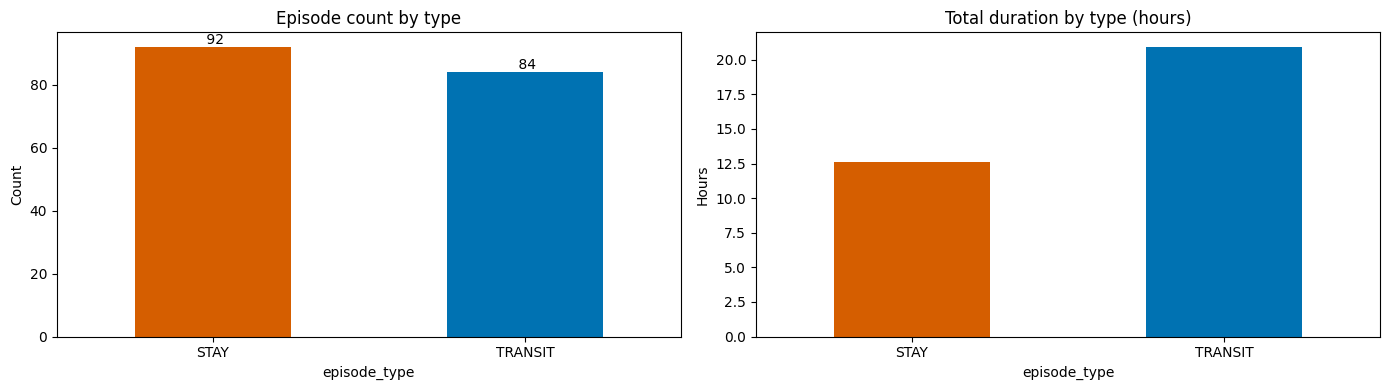

In [19]:
ep_type_counts = episodes["episode_type"].value_counts()
ep_total_duration_h = episodes.groupby("episode_type")["duration_s"].sum() / 3600
fig, ax = plt.subplots(1, 2, figsize=(14, 4))
ep_type_counts.plot.bar(ax=ax[0], color=["#D55E00", "#0072B2"])
ax[0].set_title("Episode count by type")
ax[0].set_ylabel("Count")
ax[0].tick_params(axis="x", rotation=0)
for i, count in enumerate(ep_type_counts):
    ax[0].text(i, count, f" {count}", ha="center", va="bottom")
ep_total_duration_h.plot.bar(ax=ax[1], color=["#D55E00", "#0072B2"])
ax[1].set_title("Total duration by type (hours)")
ax[1].set_ylabel("Hours")
ax[1].tick_params(axis="x", rotation=0)
plt.tight_layout()
plt.show()

## 15. Anatomy of one TRANSIT episode

One TRANSIT with its constituent segments coloured individually —
the segment boundaries inside a single journey become visible.

In [20]:
def _episode_path_polyline(
    fmap: folium.Map,
    episode: pd.Series,
    rank: int = 0,
    is_query: bool = False,
) -> None:
    """Draw an episode's constituent segments through actual pings."""
    seg_ids = list(episode["segment_ids"])
    for sid in seg_ids:
        seg_pings = per_ping_segmented[per_ping_segmented["segment_id"] == sid]
        if len(seg_pings) < 2:
            continue
        seg_meta_row = segments.loc[segments["segment_id"] == sid]
        if len(seg_meta_row) == 0:
            continue
        seg_type = str(seg_meta_row.iloc[0]["segment_type"])
        if is_query:
            colour = "#000000"
            weight = 5.0
            opacity = 0.95
        else:
            colour = COLOUR.get(seg_type, "#1f77b4")
            weight = 3.0
            opacity = float(max(0.35, 0.9 - rank * 0.12))
        folium.PolyLine(
            locations=list(zip(seg_pings["lat"].astype(float),
                               seg_pings["lon"].astype(float),
                               strict=True)),
            color=colour,
            weight=weight,
            opacity=opacity,
            tooltip=(
                f"ep={episode['episode_id']} rank={rank} "
                f"seg={sid} {seg_type}"
            ),
        ).add_to(fmap)


sample_transit = episodes[episodes["episode_type"] == "TRANSIT"].sort_values(
    "n_segments", ascending=False
).iloc[0]
print(
    f"Episode {sample_transit['episode_id']}  "
    f"({sample_transit['episode_type']}, {sample_transit['duration_s']:.0f}s, "
    f"{int(sample_transit['n_segments'])} segments, "
    f"{float(sample_transit['path_length_m']):.0f}m path)"
)
seg_type_in_ep = []
for sid in sample_transit["segment_ids"]:
    s = segments.loc[segments["segment_id"] == sid].iloc[0]
    seg_type_in_ep.append(s["segment_type"])
print("  Segment-type composition:",
      pd.Series(seg_type_in_ep).value_counts().to_dict())

# Centre on this episode
ep_pings_subset = per_ping_segmented[
    per_ping_segmented["segment_id"].isin(sample_transit["segment_ids"])
]
ep_center_lat = float(ep_pings_subset["lat"].mean())
ep_center_lon = float(ep_pings_subset["lon"].mean())

m_one_ep = folium.Map(
    location=[ep_center_lat, ep_center_lon], zoom_start=14, tiles="cartodbpositron"
)
_episode_path_polyline(m_one_ep, sample_transit, rank=0, is_query=False)
folium.CircleMarker(
    location=[float(sample_transit["start_lat"]), float(sample_transit["start_lon"])],
    radius=7, color="#2ca02c", fill=True, fill_opacity=0.9,
    tooltip="episode start",
).add_to(m_one_ep)
folium.CircleMarker(
    location=[float(sample_transit["end_lat"]), float(sample_transit["end_lon"])],
    radius=7, color="#9467bd", fill=True, fill_opacity=0.9,
    tooltip="episode end",
).add_to(m_one_ep)
m_one_ep.get_root().html.add_child(folium.Element(legend_html))
m_one_ep.save("episode_anatomy.html")
m_one_ep

Episode ep_000_00150  (TRANSIT, 3968s, 25 segments, 13335m path)
  Segment-type composition: {'MOVE': 17, 'STOP_BRIEF': 7, 'MOVE_BRIEF': 1}


Each colour change along the journey is a segment boundary —
stretches of `MOVE` interrupted by short `STOP_BRIEF` blocks (traffic
lights) or `MOVE_BRIEF` chunks (parking-lot manoeuvring).

## 16. Anatomy of one STAY episode — the running-anchor rule in action

Pick a STAY with several constituent segments. Reconstruct the
running anchor at each acceptance step (the mean of the centroids of
all accepted-so-far segments) and overlay them on the map. The
anchor wanders early when only one or two segments have been
absorbed; as more come in, it settles. The final anchor is the
canonical STAY location reported by `detect_episodes`. The red
circle is the `R_m` envelope around that anchor — every constituent
segment's endpoints sat inside it.

In [21]:
_stays_multi = episodes[
    (episodes["episode_type"] == "STAY") & (episodes["n_segments"] >= 4)
].sort_values("n_segments", ascending=False)
m_stay_anat: folium.Map | None = None
if len(_stays_multi) > 0:
    _stay = _stays_multi.iloc[0]
    _const_ids = list(_stay["segment_ids"])
    _const = segments.set_index("segment_id").loc[_const_ids].reset_index()
    _const["__cent_lat"] = (_const["start_lat"] + _const["end_lat"]) / 2.0
    _const["__cent_lon"] = (_const["start_lon"] + _const["end_lon"]) / 2.0
    _running_lat: list[float] = []
    _running_lon: list[float] = []
    for _k in range(len(_const)):
        _running_lat.append(float(_const["__cent_lat"].iloc[: _k + 1].mean()))
        _running_lon.append(float(_const["__cent_lon"].iloc[: _k + 1].mean()))

    print(
        f"STAY {_stay['episode_id']}  n_segments={int(_stay['n_segments'])}  "
        f"duration={float(_stay['duration_s']):.0f}s  "
        f"envelope_radius_m={float(_stay['envelope_radius_m']):.1f}"
    )

    _n = len(_const)
    _anchor_cols: list[str] = []
    for _k in range(_n):
        _t = _k / max(_n - 1, 1)
        _r = int(255 * (0.25 + 0.6 * _t))
        _g = int(255 * (0.0 + 0.85 * _t))
        _b = int(255 * (0.55 - 0.45 * _t))
        _anchor_cols.append(f"#{_r:02x}{_g:02x}{_b:02x}")

    m_stay_anat = folium.Map(
        location=[float(_stay["anchor_lat"]), float(_stay["anchor_lon"])],
        zoom_start=18, tiles="cartodbpositron",
    )
    for _sid in _const_ids:
        _sp = per_ping_segmented[per_ping_segmented["segment_id"] == _sid]
        if len(_sp) < 2:
            continue
        _stype = str(segments.loc[segments["segment_id"] == _sid].iloc[0]["segment_type"])
        folium.PolyLine(
            locations=list(zip(_sp["lat"].astype(float),
                               _sp["lon"].astype(float), strict=True)),
            color=COLOUR.get(_stype, "#888"),
            weight=3, opacity=0.55,
            tooltip=f"{_sid} ({_stype})",
        ).add_to(m_stay_anat)

    for _k in range(_n):
        folium.CircleMarker(
            location=[_running_lat[_k], _running_lon[_k]],
            radius=7, color=_anchor_cols[_k],
            fill=True, fill_opacity=0.95, weight=2,
            tooltip=(
                f"step {_k}: anchor after accepting "
                f"{_const['segment_id'].iloc[_k]}"
            ),
        ).add_to(m_stay_anat)

    folium.Circle(
        location=[float(_stay["anchor_lat"]), float(_stay["anchor_lon"])],
        radius=EP_PARAMS.R_m,
        color="#d62728", weight=2, fill=False,
        tooltip=f"final envelope: R_m = {EP_PARAMS.R_m:.0f} m",
    ).add_to(m_stay_anat)

    m_stay_anat.get_root().html.add_child(folium.Element(legend_html))
    m_stay_anat.save("stay_anatomy.html")
else:
    print("No STAY with ≥4 segments in this slice — anatomy demo skipped.")
m_stay_anat

STAY ep_000_00082  n_segments=33  duration=1920s  envelope_radius_m=18.4


Anchor dots progress purple → yellow as each new segment is accepted
into the envelope. Watch the early steps "wander" before settling —
that's the running mean adapting to where the entity actually was.
The final anchor (last yellow dot, which sits at the same lat/lon
`detect_episodes` reports) is at the centre of the red `R_m`
envelope, and by construction every constituent segment's endpoints
fit inside that circle.

## 17. TRANSIT similarity — *"find me trips like this trip"*

A trip is a sequence, not a bag of segments. Pooling per-segment
vectors (mean / std / max) discards order and washes out the
shape signal that `embed_segments` worked to encode — and the
raw episode-level scalars added to compensate then dominate the
L2-normalised pool. The honest fix is not to rebalance the pool
but to ask: what *is* a trip, and which features actually
distinguish two trips?

Each block below answers one such question:

* **Motion-state mix** (4 dims) — fraction of duration in each
  segment type. Captures stop-and-go vs sustained structure.
* **Structure** (2 dims) — state-transition count, log
  segment-count. How chunked was the trip?
* **Speed signature during `MOVE`** (3 dims) — mean / max / std
  of per-segment mean speed across the trip's `MOVE` segments.
  Lets cosine separate walks from drives without classifying
  transport modes the segmenter never labelled.
* **Scale** (3 dims) — log of duration, path, displacement.
* **Trip shape** (2 dims) — end-to-end straightness and
  path-weighted mean per-step curvature.
* **Time context** (4 dims) — cyclic hour-of-day and day-of-week.

**Metric, threshold, and query choice are all data-driven.** Each
feature is standardised (subtract column mean, divide by column
std) so a 1-σ deviation in any feature contributes equally to the
pairwise distance. The metric is **Euclidean** rather than cosine:
cosine on standardised vectors rewards "both unusually large on the
same axis," which lets a single bimodal feature (e.g. `MOVE` speed
splitting walks vs drives) dominate the score. Euclidean asks the
more intuitive question — "how close are you in z-space" — and lets
every axis contribute proportionally to actual distance.

The similarity threshold is the **5th percentile of all pairwise
distances**: a hit is admitted only if it sits closer than 95 % of
random pairs do. The query itself is chosen as the trip with the
most neighbours under this threshold — so the demo lands on a
corner of the corpus where similarity actually *has* neighbours to
find, rather than between clusters where no metric could help.

The query is rendered in **black**, hits in colour by rank with
decreasing opacity. The hits list is whatever survives the
threshold — no `k`-padding.

In [22]:
_SEG_TYPE_ORDER = ("MOVE", "MOVE_BRIEF", "STOP_BRIEF", "STOP_DWELL")


def _transit_features(ep_row: pd.Series, seg_subset: pd.DataFrame) -> dict[str, float]:
    """Trip-native features for one TRANSIT episode.

    ``seg_subset`` is the rows of ``segments`` belonging to ``ep_row``,
    in time order. Returns a dict so the column ordering is explicit
    and self-documenting; the caller stacks into a frame.
    """
    dur = float(ep_row["duration_s"])
    path = float(ep_row["path_length_m"] or 0.0)
    disp = float(ep_row["displacement_m"] or 0.0)

    seg_dur = seg_subset["duration_s"].to_numpy(dtype=np.float64)
    seg_type = seg_subset["segment_type"].to_numpy()
    total_dur = max(seg_dur.sum(), 1e-9)
    mix = {t: 0.0 for t in _SEG_TYPE_ORDER}
    for t, d in zip(seg_type, seg_dur, strict=True):
        if t in mix:
            mix[t] += d / total_dur

    n_state_trans = (
        int((seg_type[1:] != seg_type[:-1]).sum()) if len(seg_type) > 1 else 0
    )

    move_mask = seg_type == "MOVE"
    move_speeds = seg_subset.loc[move_mask, "mean_speed_ms"].dropna().to_numpy()
    if len(move_speeds) > 0:
        mean_move = float(move_speeds.mean())
        max_move = float(move_speeds.max())
        std_move = float(move_speeds.std()) if len(move_speeds) > 1 else 0.0
    else:
        mean_move = max_move = std_move = 0.0

    # Clip: rare ping-gaps inside the episode let `displacement_m` slightly
    # exceed the sum of per-segment `path_length_m`.
    straightness = float(min(disp / path, 1.0)) if path > 0 else 0.0
    seg_curv = seg_subset["shape_abs_delta_p95_deg"].fillna(0.0).to_numpy()
    seg_path = seg_subset["path_length_m"].fillna(0.0).to_numpy()
    trip_turning = float((seg_curv * seg_path).sum() / max(seg_path.sum(), 1e-9))

    start_ts = pd.Timestamp(ep_row["start_ts"])
    hod = (start_ts.hour + start_ts.minute / 60.0) / 24.0
    dow = start_ts.dayofweek / 7.0

    return {
        # Motion-state mix
        "frac_MOVE":         mix["MOVE"],
        "frac_MOVE_BRIEF":   mix["MOVE_BRIEF"],
        "frac_STOP_BRIEF":   mix["STOP_BRIEF"],
        "frac_STOP_DWELL":   mix["STOP_DWELL"],
        # Structure
        "n_state_trans":     float(n_state_trans),
        "log_n_segments":    float(np.log1p(float(ep_row["n_segments"]))),
        # Speed signature during MOVE
        "mean_move_speed":   mean_move,
        "max_move_speed":    max_move,
        "std_move_speed":    std_move,
        # Scale
        "log_duration_s":    float(np.log1p(max(dur, 0.0))),
        "log_path_m":        float(np.log1p(max(path, 0.0))),
        "log_displacement":  float(np.log1p(max(disp, 0.0))),
        # Trip shape
        "straightness":      straightness,
        "trip_turning_deg":  trip_turning,
        # Time context
        "hod_sin":           float(np.sin(2 * np.pi * hod)),
        "hod_cos":           float(np.cos(2 * np.pi * hod)),
        "dow_sin":           float(np.sin(2 * np.pi * dow)),
        "dow_cos":           float(np.cos(2 * np.pi * dow)),
    }


transits = episodes[episodes["episode_type"] == "TRANSIT"].reset_index(drop=True)
_seg_by_id = segments.set_index("segment_id")

_rows: list[dict[str, float]] = []
_ids: list[str] = []
for _, _ep in transits.iterrows():
    _seg_subset = _seg_by_id.loc[list(_ep["segment_ids"])].reset_index()
    _rows.append(_transit_features(_ep, _seg_subset))
    _ids.append(str(_ep["episode_id"]))

tr_features = pd.DataFrame(_rows, index=_ids)
print(f"TRANSIT episodes: {len(tr_features)}, features: {tr_features.shape[1]}")

# Standardise per-column so a 1-σ deviation contributes equally on every axis.
_tr_mu = tr_features.mean()
_tr_sd = tr_features.std().replace(0.0, 1.0)
_Z = ((tr_features - _tr_mu) / _tr_sd).to_numpy(dtype=np.float32)

# Pairwise Euclidean distances (corpus small enough for full matrix; for
# larger corpora, estimate the percentile from a random sample of pairs).
_D = np.sqrt(((_Z[:, None, :] - _Z[None, :, :]) ** 2).sum(axis=2))
_upper = _D[np.triu_indices(len(_Z), k=1)]
TR_THRESH = float(np.percentile(_upper, 5))
print(
    f"Distance threshold (5th percentile of pairwise dists): {TR_THRESH:.2f}"
)

# Pick the query: the trip with the most neighbours within threshold.
# Honest, data-driven, and lands the demo on a well-supported part of
# the corpus (rather than between clusters).
m_ep_sim = None
if len(_Z) > 1:
    _neighbour_counts = (_D <= TR_THRESH).sum(axis=1) - 1  # exclude self
    _q_idx = int(np.argmax(_neighbour_counts))
    query_ep_id = _ids[_q_idx]

    _within = np.where(_D[_q_idx] <= TR_THRESH)[0]
    _within = _within[np.argsort(_D[_q_idx, _within])]

    _hit_rows = []
    for _rank, _j in enumerate(_within):
        _ep = transits.loc[transits["episode_id"] == _ids[_j]].iloc[0]
        _f = tr_features.iloc[_j]
        _hit_rows.append({
            "rank":     _rank,
            "episode_id": _ids[_j],
            "dist":     round(float(_D[_q_idx, _j]), 2),
            "dur_min":  int(round(float(_ep["duration_s"]) / 60)),
            "path_km":  round(float(_ep["path_length_m"]) / 1000, 1),
            "n_segs":   int(_ep["n_segments"]),
            "move_pct": int(round(_f["frac_MOVE"] * 100)),
            "stop_pct": int(round(_f["frac_STOP_BRIEF"] * 100)),
            "v_ms":     round(_f["mean_move_speed"], 1),
            "straight": round(_f["straightness"], 2),
        })
    hits_table = pd.DataFrame(_hit_rows)

    print(
        f"\nQuery: {query_ep_id}  "
        f"({len(_within) - 1} hits within threshold)"
    )
    print(hits_table.to_string(index=False))

    # One colour per *trip* (not per segment), so neighbouring hits
    # read as distinct polylines rather than a stack of MOVE/STOP_BRIEF
    # blobs. Query is black; hits sample the viridis colormap by rank.
    import matplotlib.cm as _cm  # noqa: E402, PLC0415
    _n_hits = max(len(hits_table) - 1, 1)
    _hit_palette = [
        "#{:02x}{:02x}{:02x}".format(*(int(255 * c) for c in _cm.viridis(i / _n_hits)[:3]))
        for i in range(_n_hits)
    ]

    m_ep_sim = folium.Map(
        location=[center_lat, center_lon], zoom_start=12, tiles="cartodbpositron"
    )
    for _, _row in hits_table.iterrows():
        _ep_row = transits.loc[transits["episode_id"] == _row["episode_id"]].iloc[0]
        _is_query = _row["rank"] == 0
        _trip_pings = per_ping_segmented[
            per_ping_segmented["segment_id"].isin(_ep_row["segment_ids"])
        ]
        if len(_trip_pings) < 2:
            continue
        _colour = "#000000" if _is_query else _hit_palette[int(_row["rank"]) - 1]
        folium.PolyLine(
            locations=list(zip(
                _trip_pings["lat"].astype(float),
                _trip_pings["lon"].astype(float),
                strict=True,
            )),
            color=_colour,
            weight=6 if _is_query else 3,
            opacity=0.95 if _is_query else 0.75,
            tooltip=(
                f"rank={int(_row['rank'])} dist={_row['dist']:.2f} "
                f"{_row['episode_id']} • {_row['dur_min']} min • "
                f"{_row['path_km']} km • v={_row['v_ms']} m/s"
            ),
        ).add_to(m_ep_sim)
    m_ep_sim.save("episode_similarity_map.html")
else:
    print("Need at least 2 TRANSITs for a similarity demo.")

m_ep_sim

TRANSIT episodes: 84, features: 18
Distance threshold (5th percentile of pairwise dists): 2.80

Query: ep_000_00171  (16 hits within threshold)
 rank   episode_id  dist  dur_min  path_km  n_segs  move_pct  stop_pct  v_ms  straight
    0 ep_000_00171  0.00        8      1.7       6        92         8   3.4      0.53
    1 ep_000_00169  1.90        5      1.0       2       100         0   3.3      0.48
    2 ep_000_00011  1.97       12      1.7       5        93         7   2.5      0.69
    3 ep_000_00167  2.13        8      2.0       3        92         8   5.0      0.84
    4 ep_000_00172  2.15        8      1.1       4        91         9   2.6      1.00
    5 ep_000_00013  2.30       22      3.1       6        97         3   2.2      0.73
    6 ep_000_00136  2.31        9      1.5       2       100         0   1.8      0.59
    7 ep_000_00175  2.39        6      0.3       3        92         8   2.1      0.35
    8 ep_000_00012  2.45        7      1.7       2       100         0   

Hits should share the query's scale, motion-state mix, speed band,
and shape — and land geographically scattered, since neither spatial
coordinates nor anchor location enter the trip vector. Compare
against the segment-similarity map (§10): segments match on shape
because their vector encodes shape directly; trips now match on
trip-shaped features for the same reason.

If a query returns no hits within threshold, the embedding is being
honest — the trip is genuinely isolated in feature space and no
nearest-neighbour is meaningfully *similar*. Tighten the threshold
(smaller percentile) for stricter matches, or relax it to surface
weak analogies; either is a user-side decision over the same
feature frame.

## 17b. STAY similarity — *"find me dwells like this dwell"*

STAYs are points in space-time, not paths. Their internal segments
are jitter around an anchor, not structure to compare. The honest
STAY vector is small: duration class plus when it happened.

* **Scale** (1 dim) — log duration.
* **Time context** (4 dims) — cyclic hour-of-day and day-of-week.

Same data-driven recipe as §17: standardise, Euclidean distance,
threshold at the 5th percentile of pairwise distances, query =
best-supported STAY, return all hits within threshold. 5 dims is
enough because the question itself is simple — adding mode-mix or
shape here would just inject noise that doesn't correspond to
anything a user means by "similar dwell."

In [23]:
def _stay_features(ep_row: pd.Series) -> dict[str, float]:
    """Trip-free STAY features: duration + cyclic time-of-day/week."""
    dur = float(ep_row["duration_s"])
    start_ts = pd.Timestamp(ep_row["start_ts"])
    hod = (start_ts.hour + start_ts.minute / 60.0) / 24.0
    dow = start_ts.dayofweek / 7.0
    return {
        "log_duration_s": float(np.log1p(max(dur, 0.0))),
        "hod_sin": float(np.sin(2 * np.pi * hod)),
        "hod_cos": float(np.cos(2 * np.pi * hod)),
        "dow_sin": float(np.sin(2 * np.pi * dow)),
        "dow_cos": float(np.cos(2 * np.pi * dow)),
    }


_stays_df = episodes[episodes["episode_type"] == "STAY"].reset_index(drop=True)
stay_features = pd.DataFrame(
    [_stay_features(_r) for _, _r in _stays_df.iterrows()],
    index=_stays_df["episode_id"].astype(str).tolist(),
)
print(f"STAY episodes: {len(stay_features)}, features: {stay_features.shape[1]}")

_s_mu = stay_features.mean()
_s_sd = stay_features.std().replace(0.0, 1.0)
_S = ((stay_features - _s_mu) / _s_sd).to_numpy(dtype=np.float32)

m_stay_sim = None
if len(_S) > 1:
    _DS = np.sqrt(((_S[:, None, :] - _S[None, :, :]) ** 2).sum(axis=2))
    _su = _DS[np.triu_indices(len(_S), k=1)]
    STAY_THRESH = float(np.percentile(_su, 5))
    print(
        f"Distance threshold (5th percentile of pairwise dists): {STAY_THRESH:.2f}"
    )

    _nc = (_DS <= STAY_THRESH).sum(axis=1) - 1
    _q_idx = int(np.argmax(_nc))
    _q_id = list(stay_features.index)[_q_idx]

    _within = np.where(_DS[_q_idx] <= STAY_THRESH)[0]
    _within = _within[np.argsort(_DS[_q_idx, _within])]

    _hit_rows = []
    for _rank, _j in enumerate(_within):
        _ep = _stays_df.iloc[_j]
        _hit_rows.append({
            "rank": _rank,
            "episode_id": str(_ep["episode_id"]),
            "dist": round(float(_DS[_q_idx, _j]), 2),
            "dur_min": int(round(float(_ep["duration_s"]) / 60)),
            "start": pd.Timestamp(_ep["start_ts"]).strftime("%a %H:%M"),
        })
    hits_table_stay = pd.DataFrame(_hit_rows)

    print(
        f"\nQuery: {_q_id}  "
        f"({len(_within) - 1} hits within threshold)"
    )
    print(hits_table_stay.to_string(index=False))

    # Map: query in black, hits each get a distinct colour sampled from
    # the viridis colormap by rank — so even with many hits, every
    # anchor is visually separable.
    import matplotlib.cm as _cm  # noqa: E402, PLC0415
    _n_stay_hits = max(len(hits_table_stay) - 1, 1)
    _stay_palette = [
        "#{:02x}{:02x}{:02x}".format(*(int(255 * c) for c in _cm.viridis(i / _n_stay_hits)[:3]))
        for i in range(_n_stay_hits)
    ]
    m_stay_sim = folium.Map(
        location=[center_lat, center_lon], zoom_start=12, tiles="cartodbpositron"
    )
    for _, _row in hits_table_stay.iterrows():
        _ep = _stays_df.loc[_stays_df["episode_id"] == _row["episode_id"]].iloc[0]
        _is_query = _row["rank"] == 0
        _col = "#000000" if _is_query else _stay_palette[int(_row["rank"]) - 1]
        folium.CircleMarker(
            location=[float(_ep["anchor_lat"]), float(_ep["anchor_lon"])],
            radius=12 if _is_query else 8,
            color=_col,
            weight=3 if _is_query else 2,
            fill=True,
            fill_opacity=0.9 if _is_query else 0.6,
            tooltip=(
                f"rank={int(_row['rank'])} dist={_row['dist']:.2f} "
                f"{_row['episode_id']} • {_row['dur_min']} min • {_row['start']}"
            ),
        ).add_to(m_stay_sim)
    m_stay_sim.save("stay_similarity_map.html")
else:
    print("Need at least 2 STAYs for a similarity demo.")

m_stay_sim

STAY episodes: 92, features: 5
Distance threshold (5th percentile of pairwise dists): 1.11

Query: ep_000_00070  (14 hits within threshold)
 rank   episode_id  dist  dur_min     start
    0 ep_000_00070  0.00       10 Fri 16:18
    1 ep_000_00071  0.32        8 Fri 16:35
    2 ep_000_00073  0.42        9 Fri 17:27
    3 ep_000_00069  0.42       14 Fri 15:59
    4 ep_000_00067  0.68       13 Fri 14:42
    5 ep_000_00074  0.69        7 Fri 17:37
    6 ep_000_00079  0.79       11 Fri 18:28
    7 ep_000_00065  0.91        6 Fri 14:17
    8 ep_000_00064  0.91       12 Fri 13:58
    9 ep_000_00081  0.93        8 Fri 18:52
   10 ep_000_00072  0.95       20 Fri 17:02
   11 ep_000_00075  1.00        5 Fri 17:50
   12 ep_000_00078  1.00        6 Fri 18:22
   13 ep_000_00076  1.01       19 Fri 17:55
   14 ep_000_00061  1.08        8 Fri 13:26


## 18. Does similarity actually retrieve same-kind segments?

The closer is a quantitative check on whether the embedding does the
job `compare` advertises. For every segment in the corpus, take its
`k` nearest neighbours (excluding the query itself). Count how many
share the query's `segment_type`. Average across all segments.

The right random baseline is type-specific. For a query of type T,
random neighbours drawn from the corpus would match T at the rate of
T's corpus share. So the per-type baseline is just that share —
45% for MOVE, 1% for STOP_DWELL. The aggregate baseline (`Σ p_i²`)
is what a random embedding would produce averaged across all
segments.

Neighbour purity at k=10: 88.5%  (aggregate random baseline: 38.1%)

Per-type purity (lift = observed / type's own random baseline):
  type             n   share   purity   baseline   lift
  MOVE           425   45.4%    92.6%      45.4%   2.0×
  STOP_BRIEF     368   39.3%    93.8%      39.3%   2.4×
  MOVE_BRIEF     135   14.4%    66.7%      14.4%   4.6×
  STOP_DWELL       9    1.0%    11.1%       1.0%  11.6×


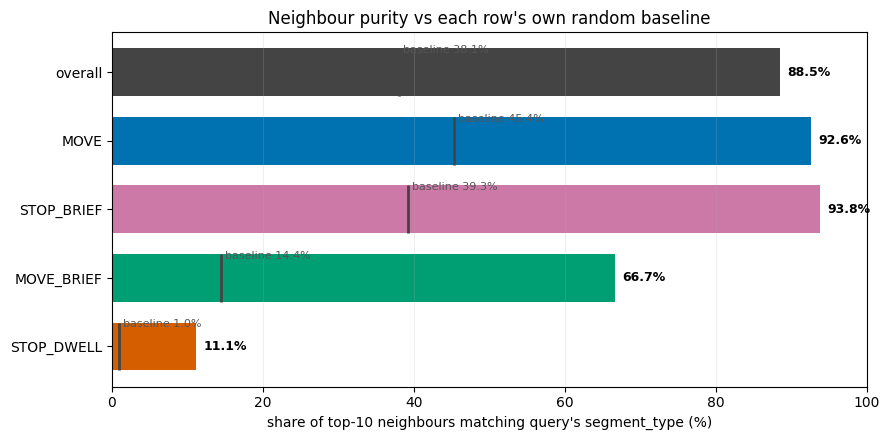

In [24]:
_K = 10
_types_arr = (
    segments.set_index("segment_id")
    .loc[seg_ids]["segment_type"]
    .to_numpy()
)
_type_counts = pd.Series(_types_arr).value_counts()
_type_props = _type_counts / len(_types_arr)
_proportional = float((_type_props ** 2).sum())

# Reuse the segment index built in section 10.
_per_type_hits: dict[str, list[float]] = {t: [] for t in _type_counts.index}
_overall: list[float] = []
_id_to_row = {sid: i for i, sid in enumerate(seg_ids)}

for _qi, _qid in enumerate(seg_ids):
    _qtype = _types_arr[_qi]
    _hits = search(_seg_index, seg_vectors[_qi], k=_K + 1)
    _nb_types = [
        _types_arr[_id_to_row[h.id]]
        for h in _hits if h.id != _qid
    ][:_K]
    if not _nb_types:
        continue
    _frac = sum(1 for t in _nb_types if t == _qtype) / len(_nb_types)
    _overall.append(_frac)
    _per_type_hits[_qtype].append(_frac)

_overall_purity = float(np.mean(_overall))
_per_type_purity = {
    t: float(np.mean(v)) if v else float("nan")
    for t, v in _per_type_hits.items()
}

print(f"Neighbour purity at k={_K}: {100*_overall_purity:.1f}%  "
      f"(aggregate random baseline: {100*_proportional:.1f}%)")
print(f"\nPer-type purity (lift = observed / type's own random baseline):")
print(f"  {'type':<12s}  {'n':>4s}  {'share':>6s}  {'purity':>7s}  {'baseline':>9s}  {'lift':>5s}")
for _t in _type_counts.index:
    _share = float(_type_props[_t])
    _obs = _per_type_purity[_t]
    _lift = _obs / _share if _share > 0 else float("inf")
    print(f"  {_t:<12s}  {int(_type_counts[_t]):>4d}  "
          f"{_share*100:>5.1f}%  "
          f"{_obs*100:>6.1f}%  "
          f"{_share*100:>8.1f}%  "
          f"{_lift:>4.1f}×")

# Bar chart: per-bar baseline marker for fair per-type comparison.
fig, ax = plt.subplots(figsize=(9, 4.5))
_labels = ["overall"] + list(_type_counts.index)
_vals = [_overall_purity] + [_per_type_purity[t] for t in _type_counts.index]
_baselines = [_proportional] + [float(_type_props[t]) for t in _type_counts.index]
_colours = ["#444444"] + [COLOUR[t] for t in _type_counts.index]
_y_positions = np.arange(len(_labels))
_bars = ax.barh(_y_positions, [100 * v for v in _vals],
                color=_colours, height=0.7)
ax.set_yticks(_y_positions)
ax.set_yticklabels(_labels)

# Per-bar baseline as a vertical tick spanning the bar's height.
for _y, _base in zip(_y_positions, _baselines, strict=True):
    ax.plot(
        [100 * _base, 100 * _base],
        [_y - 0.35, _y + 0.35],
        color="#444", lw=2, solid_capstyle="butt",
    )
    ax.text(100 * _base + 0.5, _y - 0.40, f"baseline {100*_base:.1f}%",
            fontsize=8, color="#555", va="top")

ax.set_xlim(0, 100)
ax.set_xlabel(f"share of top-{_K} neighbours matching query's segment_type (%)")
ax.set_title("Neighbour purity vs each row's own random baseline")
ax.invert_yaxis()
ax.grid(True, alpha=0.2, axis="x")
for bar, val in zip(_bars, _vals, strict=True):
    ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height() / 2,
            f"{100*val:.1f}%", va="center", fontsize=9, fontweight="bold")
plt.tight_layout(); plt.show()

Reading the result:

* **MOVE** and **STOP_BRIEF** are the two large, internally
  consistent classes — purity hovers around 93% against a 45%/39%
  baseline. Roughly 2× lift, near the ceiling for retrieval on these
  classes.
* **MOVE_BRIEF** sits geometrically between MOVE and STOP_BRIEF in
  feature space (brief move = "kind of stop, kind of move"), so its
  top-`k` mixes both. Still 4.6× above its baseline.
* **STOP_DWELL** has only 9 examples in this slice. Asking for
  k=10 same-type neighbours is asking for more than exists, so
  absolute purity is bounded at ~(9−1)/10 = 80%. The 11.1% reading
  is **11× its own baseline** — actually the strongest per-class
  lift in the corpus, just constrained by data thinness.

Every class is well above its own random baseline. The recipe is
doing real retrieval; the visible variation in absolute purity
tracks corpus composition and class-overlap geometry, not embedding
quality.

## Closing

Each section above ties one design decision to its visible effect on a
real trace. For the full design rationale — why circular-R over rolling
bearing deltas, why distance-based windows, why a dual qualification
gate on episodes — see `docs/design/{segment,episode,embed,compare}.md`.